# Day 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras

## 기반 모델

In [4]:
from keras.applications.vgg16 import VGG16

기반모델 = VGG16(weights='imagenet', include_top=False)
기반모델.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## 응용 모델

In [ ]:
def get_model(기반모델):
    model = keras.Sequential()
    model.add(keras.Input(shape=(180, 180, 3)))
    model.add(기반모델)
    # 응용 출력: "New Top"
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(256, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    return model

기반모델.trainable = False # 가중치 고정; "동결"
model = get_model(기반모델)
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# %load catdog.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image as Image
import torch

class CatDogDataset:
    def __init__(self, 폴더, transform=None):
        self.폴더 = Path(폴더)
        self.파일들 = list(self.폴더.glob('**/*.jpg'))
        self.labels = {'cat': 0, 'dog': 1}
        self.transform = transform
    
    def __len__(self):
        return len(self.파일들)
    
    def __getitem__(self, 색인):
        파일 = self.파일들[색인]
        target = self.labels['cat' if 'cat' in 파일.stem else 'dog']
        with Image.open(파일) as img:
            sample = img.copy()
        if self.transform:
            sample = self.transform(sample)
        return sample, target
    

def get_datasets(폴더, transform=None):
    print('# 데이터셋')
    datasets = {}
    for 하위폴더 in Path(폴더).iterdir():
        split = 하위폴더.stem
        datasets[split] = CatDogDataset(하위폴더, transform=transform)
        print(f'{split:<10}: {len(datasets[split]):,} samples')
    return datasets

def get_dataloaders(datasets, **설정):
    print('# 데이터로더')
    dataloaders = {}
    for split in datasets.keys():
        dataloaders[split] = torch.utils.data.DataLoader(
            datasets[split], shuffle=(split=='train'),
            **설정
        )
        print(f'{split:<10}: {len(dataloaders[split]):,} batches')
    return dataloaders

def get_train_results(history, plot=True):
    train_results = pd.DataFrame(history.history)
    if plot:
        plt.figure(figsize=(10, 4))
        왼쪽 = plt.subplot(1, 2, 1) # 1행 2열의 1번째 위치
        train_results.plot(y=['loss', 'val_loss'], ax=왼쪽)
        오른쪽 = plt.subplot(1, 2, 2) # 1행 2열의 2번째 위치
        train_results.plot(y=['accuracy', 'val_accuracy'], ax=오른쪽)
        plt.tight_layout()
        plt.show()
    return train_results

def evaluate_model(model, dataloader):
    results = model.evaluate(dataloader, return_dict=True)
    return pd.Series(results)

## 전처리

In [49]:
from pathlib import Path
import torchvision.transforms as T
from keras.applications.vgg16 import preprocess_input

%run catdog.py

전처리 = T.Compose([
    T.Resize((180, 180)),
    T.ToTensor(),
    # Channel First -> Channel Last
    # (C, H, W) -> (H, W, C) "차원 순서 재배열"
    T.Lambda(lambda sample: sample.permute(1, 2, 0)),
    # VGG16 전처리가 기대하는 값으로 변환: [0, 1] -> [0, 255]
    T.Lambda(lambda sample: sample * 255),
    T.Lambda(lambda sample: preprocess_input(sample.numpy())),
    # numpy -> torch.Tensor
    T.Lambda(lambda sample: torch.from_numpy(sample.copy()))
])

폴더 = Path('data/cats_dogs_small')
datasets = get_datasets(폴더, transform=전처리)
dataloaders = get_dataloaders(
    datasets, batch_size=32, num_workers=4, pin_memory=True)

for X_batch, y_batch in dataloaders['train']:
    print(X_batch.shape, y_batch.shape)
    break

# 데이터셋
test      : 2,000 samples
train     : 2,000 samples
validation: 1,000 samples
# 데이터로더
test      : 63 batches
train     : 63 batches
validation: 32 batches
torch.Size([32, 180, 180, 3]) torch.Size([32])


In [29]:
sample, label = datasets['train'][0]
print(type(sample), sample.shape)
print(sample.min(), sample.max())

<class 'numpy.ndarray'> (180, 180, 3)
-121.68 131.32


## 모델 훈련

In [51]:
기반모델 = VGG16(weights='imagenet', include_top=False)
기반모델.trainable = False # 가중치 고정; "동결"
model = get_model(기반모델)

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)
history = model.fit(
    dataloaders['train'], validation_data=dataloaders['validation'],
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint('catdog.keras', save_best_only=True)
    ]
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.8098 - loss: 2.6762 - val_accuracy: 0.9570 - val_loss: 0.6297
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - accuracy: 0.9159 - loss: 1.2560 - val_accuracy: 0.9590 - val_loss: 0.5777
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.9444 - loss: 0.7848 - val_accuracy: 0.9750 - val_loss: 0.3550
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9387 - loss: 0.9315 - val_accuracy: 0.9640 - val_loss: 0.5184
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9555 - loss: 0.6632 - val_accuracy: 0.8430 - val_loss: 2.4249
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - accuracy: 0.9442 - loss: 0.8472 - val_accuracy: 0.9220 - val_loss: 1.2021
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9544 - loss: 0.7203 - val_accuracy: 0.9630 - val_loss: 0.5708
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step - accuracy: 0.9664 - loss: 0.5246 - val_accu

In [54]:
from catdog import get_train_results, evaluate_model

model = keras.models.load_model('catdog.keras')
evaluate_model(model, dataloaders['test'])

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.9557 - loss: 0.6659
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9556 - loss: 0.6666

accuracy    0.9585
loss        0.6187
dtype: float64

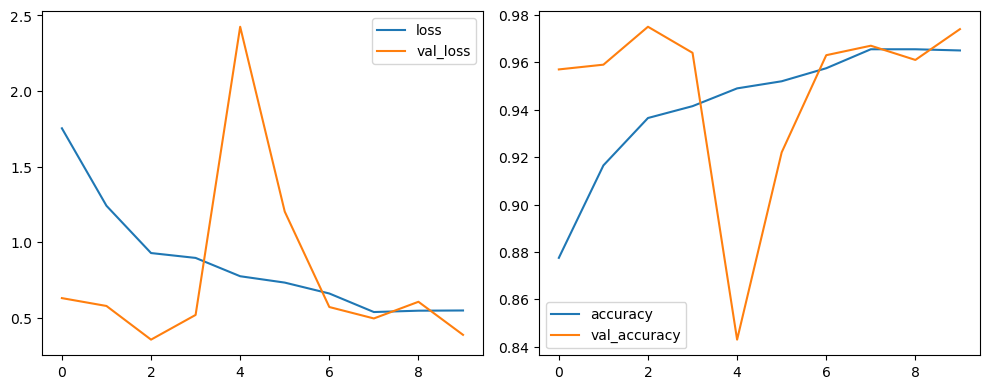

,accuracy,loss,val_accuracy,val_loss
0,0.877,1.753,0.957,0.630
1,0.916,1.241,0.959,0.578
2,0.937,0.928,0.975,0.355
3,0.942,0.896,0.964,0.518
4,0.949,0.774,0.843,2.425
5,0.952,0.732,0.922,1.202
6,0.957,0.660,0.963,0.571
7,0.965,0.538,0.967,0.495
8,0.965,0.546,0.961,0.605
9,0.965,0.548,0.974,0.387


In [57]:
train_results = get_train_results(history)
train_results.round(3)

## 활성화 분석

신경망 계층의 출력을 종종 "활성화(activation)"라고 부릅니다. 모델이 입력을 처리할 때, 각 계층은 입력에서 특징을 추출하여 다음 계층으로 전달합니다. 이 과정에서 각 계층의 출력은 모델이 입력에서 어떤 정보를 추출했는지를 보여주는 중요한 단서가 됩니다. 활성화 분석은 이러한 출력을 시각화하여 모델이 입력을 어떻게 이해하고 있는지를 탐구하는 방법입니다.

In [74]:
기반모델 = VGG16(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
활성화모델 = keras.Model(
    inputs=기반모델.input,
    outputs=[
        기반모델.get_layer('block1_pool').output,
        기반모델.get_layer('block2_pool').output,
        기반모델.get_layer('block3_pool').output,
        기반모델.get_layer('block4_pool').output,
        기반모델.get_layer('block5_pool').output,
    ]
)
활성화모델.summary()

Model: "functional_97"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from PIL import Image

with Image.open('data/mozzi.png') as img:
    sample = img.convert('RGB')

sample = 전처리(sample)
print(sample.shape)

outputs = 활성화모델.predict(sample.unsqueeze(0)) # 배치 차원 추가
# 출력이 여러 층의 활성화이므로 리스트로 반환됩니다.
print(type(outputs), len(outputs))

# 출력 시각화
def 출력시각화(출력, 레이아웃, figsize=(10, 10)):
    그림틀, 영역 = plt.subplots(*레이아웃, figsize=figsize)
    for i, 그래프 in enumerate(영역.flat):
        그래프.imshow(출력[:, :, i], cmap='gray')
        그래프.axis('off')
    return 그림틀

for i, 출력 in enumerate(outputs):
    출력 = 출력.squeeze(0) # 배치 차원 제거
    print(출력.shape)
    그림틀 = 출력시각화(
        # 열을 고정하고, 행은 자동으로 계산
        출력, 레이아웃=(출력.shape[-1] // 8, 8),
        # 가로 길이를 고정하고, 세로 길이는 채널 수에 비례하여 조정
        figsize=(10, 10 * 출력.shape[-1] // 64))
    plt.savefig(f'activation_block{i+1}.png')
    plt.close()

torch.Size([180, 180, 3])
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
<class 'list'> 5
(90, 90, 64)
(45, 45, 128)
(22, 22, 256)
(11, 11, 512)
(5, 5, 512)


## 텍스트 데이터

In [ ]:
from pathlib import Path

폴더 = Path('data/koen')
assert 폴더.is_dir(), f'{폴더} 폴더가 존재하지 않습니다.'

파일들 = list(폴더.glob('**/*.csv'))
datasets = {}
for 파일 in 파일들:
    split = 파일.stem
    datasets[split] = pd.read_csv(파일)
    print(f'{split:<10}: {len(datasets[split]):,}')

test      : 104,165
train     : 833,321
validation: 104,165


In [108]:
datasets['train'].sample(5)

,ko,en,source
162573,우리는 이것을 커뮤니티 프로그램으로 하고 싶습니다.,We really want to do this as a community program.,71265
127463,경찰은 관련 자료를 확보해 A 씨가 학교 행정실장 B(58) 씨에게 퇴직 후 일자리...,The police have secured related data and are l...,126
277566,특히 예금과 대출 등 금융거래를 하는 신용협동조합의 자본금 기준이 3억원이란 점에 ...,"In particular, it is easy to see how excessive...",126
183718,고객을 파악한다면 도움이 될 것입니다.,Knowing your customer will help you.,71265
515768,"메인 처리부(160)는 신호의 증폭, 변환, 처리 등의 전반적인 과정을 제어하는 기...",The main processing unit 160 may perform a fun...,124


In [114]:
분류코드 = datasets['train']['source']
분류코드도수 = 분류코드.value_counts()
pd.DataFrame({'도수': 분류코드도수, '비율': 분류코드도수 / sum(분류코드도수)}).round(3)

,도수,비율
source,,
71265,198471,0.238
126,128104,0.154
125,108894,0.131
124,108014,0.130
111,107520,0.129
71266,106518,0.128
71382,46831,0.056
563,28969,0.035


In [ ]:
분류필터 = datasets['train']['source'] == 71265 # 구어체 텍스트
datasets['train'][분류필터].sample(5)

,ko,en,source
625308,우리는 한방 치료를 한방이라고 부릅니다.,We call our Korean herb treatment Hanbang.,71265
766323,남성용 스탠더드 슬림 바지로 간편하게 착용할 수 있고 세탁기 사용 가능합니다.,"Men's standard slim trousers, easy to wear and...",71265
760146,그는 그날 나중에 인보이스를 이메일로 보내겠다고 말했다.,He said he'll be emailing the invoice later in...,71265
100254,>나와 봐!,>You come here!,71265
30041,저기 점원에게 물어보시면 됩니다.,You can ask the cashier over there.,71265


In [116]:
분류필터 = datasets['train']['source'] == 563 # 특허 텍스트
datasets['train'][분류필터].sample(5)

,ko,en,source
63773,본 발명은 유리한 광학 특성을 갖는 가소화제 물질(유기 인산 에스터) 및 이러한 유...,The invention relates to plasticizer substance...,563
709089,TFT의 사용시에 있어서의 전기적 스트레스의 TFT 특성에 대한 영향을 억제하기 위...,In order to suppress an influence of an electr...,563
253096,프로세싱 툴과 함께 사용하기 위한 패러데이 컵 구조물(110)이 제공된다. 컵 구조...,A Faraday cup structure for use with a process...,563
660972,오류 정정과 관련된 장치 및 방법에는 FD 디코더 및 AD 디코더 사용이 포함될 수...,Apparatuses and methods related to correcting ...,563
273001,"된장 및 된장 가공 식품의 갈변을 제조에서 유통에 이를 때까지 억제, 방지 혹은 컨...","The purpose is to suppress, prevent, or contro...",563


## 토큰화

1. 각 문장을 한 줄씩 텍스트 파일에 기록
2. sententcepiece 모델 훈련

In [125]:
with open('한국어문장.txt', 'w') as 파일:
    for 색인, 행 in datasets['train'].iterrows():
        파일.write(행['ko'] + '\n')

# 결과 확인
with open('한국어문장.txt', 'r') as 파일:
    for _ in range(5):
        print(파일.readline().strip())

지방세법 개정안에 따른 종합부동산세는 부과징수권자의 경우를 제외하고는 대부분 종전 종 합부동산세와 동일하다.
실신 당시 5초 정도 의식소실이 있었고 바로 의식은 회복되으며 신경학적 이상증상은 나타나지 않았다고 한다.
문 대통령의 10월 방일이 성사될 경우 한·일 양국은 일본군 위안부 합의 이행 문제와 독도 문제 등으로 삐걱대는 양국 관계를 개선할 계기를 만들 것이라고 신문은 전망했다.
인덱스 펀드에 대한 투자에서는 장기적인 관점에서 수익을 얻을 수 있습니다.
돌봐야 하는 비용도 있지.


In [138]:
with open('영어문장.txt', 'w') as 파일:
    for 색인, 행 in datasets['train'].iterrows():
        파일.write(행['en'] + '\n')

# 결과 확인
with open('영어문장.txt', 'r') as 파일:
    for _ in range(5):
        print(파일.readline().strip())

Comprehensive real estate tax according to the amendment to the local tax law is mostly the same as the previous comprehensive real estate tax, except for the tax collector.
At the time of fainting, there was a loss of consciousness for about 5 seconds, and consciousness was immediately restored and no neurological symptoms were observed.
If President Moon visits Japan in October, the newspaper predicted that both Korea and Japan would create an opportunity to improve the squeaky relationship between the of the agreement on the comfort women problem of the Japanese army and Dokdo.
Investment in index funds provides profitability in the long run.
I also have expenses to take care of.


```shell
pip install sentencepiece
```

In [164]:
import sentencepiece as spm

어휘수 = 30000
문장수 = 100000
spm.SentencePieceTrainer.train(
    # 유의! 각 파일경로는 공백없이 쉼표로 구분
    input='한국어문장.txt,영어문장.txt',
    model_prefix='spm',
    vocab_size=어휘수,
    # 무작위로 선택된 문장으로 모델 훈련
    input_sentence_size=문장수, # 훈련에 사용할 문장 수
    shuffle_input_sentence=True, # 입력 문장 순서 섞기
    # model_type='bpe' # Byte Pair Encoding (BPE): 1990년대
    # 특수토큰 지정
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: 한국어문장.txt
  input: 영어문장.txt
  input_format: 
  model_prefix: spm
  model_type: UNIGRAM
  vocab_size: 30000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 100000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_pri

In [166]:
예문 = [
    '한국어 문장을 형태소 단위로 분리합니다.',
    'tokenize an English sentence into subwords.',
]

tokenizer = spm.SentencePieceProcessor(model_file='spm.model')
for text in 예문:
    형태소목록 = tokenizer.encode(text, out_type=str)
    정수시퀀스 = tokenizer.encode(text, out_type=int)
    display(pd.DataFrame({
        '형태소': 형태소목록,
        '정수': 정수시퀀스
    }).T)

    텍스트복원 = tokenizer.decode(정수시퀀스)
    print(텍스트복원)

,0,1,2,3,4,5,6,7,8
형태소,▁한국어,▁문장,을,▁형태,소,▁단위로,▁분리,합니다,.
정수,9594,11558,13,2611,453,11455,1922,286,4


한국어 문장을 형태소 단위로 분리합니다.


,0,1,2,3,4,5,6,7,8,9,10,11
형태소,▁token,ize,▁an,▁English,▁sentence,▁into,▁sub,w,or,d,s,.
정수,11952,3965,40,3097,7092,178,1957,1436,255,91,14,4


tokenize an English sentence into subwords.


In [169]:
# 정수ID
pd.DataFrame({
    '토큰': [tokenizer.id_to_piece(i) for i in range(15)]
}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
토큰,<pad>,<unk>,<s>,</s>,.,▁the,",",▁of,▁,▁a,의,▁and,▁to,을,s


In [ ]:
class TextDataset:
    def __init__(self, texts, labels=None, transform=None):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, 색인):
        sample = self.texts[색인]
        if self.transform:
            sample = self.transform(sample)
            
        if self.labels is not None:
            label = self.labels[색인]
            return sample, label
        return sample

전처리 = lambda text: tokenizer.encode(text, out_type=int)

datasets = {}
for 파일경로 in 파일들:
    frame = pd.read_csv(파일경로)
    split = 파일경로.stem
    datasets[split] = TextDataset(frame['ko'], transform=전처리)

sample = datasets['train'][0]
print(sample)

[25042, 9128, 19, 402, 3211, 25396, 361, 18, 4162, 4395, 297, 14374, 10, 158, 15, 15126, 1473, 13605, 2969, 6181, 25396, 361, 46, 19095, 4]


## 텍스트 분류

In [ ]:
def 전처리(text, 최대길이):
    정수시퀀스 = tokenizer.encode(text, out_type=int)    
    return 정수시퀀스[:최대길이]

datasets = {}
for split, 샘플수 in [('train', 10000), ('validation', 1000), ('test', 1000)]:
    frame = pd.read_csv(폴더 / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거
    # 각 클래스에서 샘플링
    구어체 = frame[frame['source'] == 71265].sample(샘플수, random_state=0)
    특허 = frame[frame['source'] == 563].sample(샘플수, random_state=0)

    samples = pd.concat([구어체, 특허], ignore_index=True)
    
    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        # 텍스트 분류를 위해 클래스 레이블도 함께 제공해야 합니다.
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=lambda text: 전처리(text, 최대길이=300)
    )
    print(f'{split:<10}: {len(datasets[split]):,}')
    # 유형 도수 확인
    print(samples['source'].value_counts().to_string())

train     : 20,000
source
71265    10000
563      10000
validation: 2,000
source
71265    1000
563      1000
test      : 2,000
source
71265    1000
563      1000


In [193]:
sample, label = datasets['train'][10001]
print(f'label: {label}\nsample: {sample}')
print('복원된 텍스트:', tokenizer.decode(sample))

label: 1
sample: [628, 1579, 13, 1550, 7154, 784, 141, 147, 894, 6, 461, 6, 53, 1931, 9378, 2659, 202, 4, 1396, 1607, 1152, 13, 13143, 54, 737, 132, 2604, 38, 737, 10, 974, 13, 8580, 412, 15, 467, 4, 974, 23, 6465, 155, 886, 167, 7923, 737, 1921, 96, 21222, 1886, 160, 4]
복원된 텍스트: 새로운 특징을 네트워크 서비스에 추가하기 위한 방법, 시스템, 및 컴퓨터 프로그램이 제시된다. 방법은 관심 대상을 묘사하는 이미지 또는 그러한 이미지의 선택을 수신하는 단계를 포함한다. 선택은 후속하여 디스플레이되는 아이템 이미지들에 대한 앵커 역할을 한다.


In [229]:
문서길이 = [len(sample) for sample, _ in datasets['train']]
pd.Series(문서길이).describe().astype(int)

count    20000
mean        72
std         71
min          2
25%         11
50%         29
75%        128
max        300
dtype: int64

In [213]:
def 시퀀스패딩(sample, 최대길이, 패딩값=0):
    assert len(sample) > 0, '샘플이 비어 있습니다.'
    sample = sample[:최대길이]
    return sample + [패딩값] * (최대길이 - len(sample))

최대길이 = 20
정규화된_샘플 = []
for i in range(3):
    sample, _ = datasets['train'][i]
    정규화된_샘플.append(시퀀스패딩(sample, 최대길이))

pd.DataFrame(정규화된_샘플)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1452,1239,5221,216,3361,4496,19,332,22,9950,95,5995,61,0,0,0,0,0,0,0
1,12533,65,220,611,23,8,1980,222,193,12265,4,0,0,0,0,0,0,0,0,0
2,19553,6693,216,335,1925,3641,83,9501,47,27,153,4,0,0,0,0,0,0,0,0


In [221]:
def 배치병합(batch):
    samples, labels = zip(*batch)
    문서길이 = [len(sample) for sample in samples]
    최대길이 = max(문서길이) # 배치 내에서 가장 긴 샘플의 길이를 최대길이로 설정
    정규화된_샘플 = [시퀀스패딩(sample, 최대길이) for sample in samples]
    return np.array(정규화된_샘플), np.array(labels)

# 첫 번째 배치
sample_batch = [datasets['train'][i] for i in range(3)]
Xs, ys = 배치병합(sample_batch)
print(Xs.shape, ys.shape)
# 다른 배치
sample_batch = [datasets['train'][i] for i in range(5, 8)]
Xs, ys = 배치병합(sample_batch)
print(Xs.shape, ys.shape)

(3, 13) (3,)
(3, 22) (3,)


In [231]:
dataloaders = {}
for split in datasets.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        datasets[split], shuffle=(split=='train'),
        batch_size=32, num_workers=2, collate_fn=배치병합
    )

배치시퀀스길이 = []
for X_batch, y_batch in dataloaders['train']:
    # print(X_batch.shape, y_batch.shape)
    배치시퀀스길이.append(X_batch.shape[1])

pd.Series(배치시퀀스길이).describe().astype(int)

count    625
mean     241
std       40
min      137
25%      210
50%      236
75%      278
max      300
dtype: int64

In [255]:
import keras
from keras import layers

keras.backend.clear_session()

어휘수 = tokenizer.get_piece_size()
임베딩차원 = 64
print(f'어휘수: {어휘수}')
model = keras.Sequential([
    layers.Input(shape=(None,)), # 가변 길이 시퀀스 입력
    # 임베딩층: 정수 시퀀스를 밀집 벡터로 변환
    layers.Embedding(input_dim=어휘수, output_dim=임베딩차원),
    # 은닉층
    layers.GlobalAveragePooling1D(), # 시퀀스 차원 평균
    # layers.Dense(32, activation='relu'),
    # 출력층
    layers.Dense(1, activation='sigmoid')
])
model.summary()

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=['accuracy']
)

history = model.fit(
    dataloaders['train'], validation_data=dataloaders['validation'],
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint('text_classifier.keras', save_best_only=True)
    ]
)

어휘수: 30000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,065 (7.32 MB)

 Trainable params: 1,920,065 (7.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6982 - loss: 0.5305 - val_accuracy: 0.6105 - val_loss: 0.8764
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9574 - loss: 0.1536 - val_accuracy: 0.5655 - val_loss: 1.9511
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9753 - loss: 0.0766 - val_accuracy: 0.5515 - val_loss: 2.8894
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9851 - loss: 0.0501 - val_accuracy: 0.5400 - val_loss: 3.5362
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9857 - loss: 0.0470 - val_accuracy: 0.5460 - val_loss: 3.7382
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9847 - loss: 0.0439 - val_accuracy: 0.5405 - val_loss: 4.0429
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.5380 - val_loss: 4.2370
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9880 - loss: 0.0348 - val_accu

In [253]:
임베딩행렬 = model.layers[0].get_weights()[0]
print(f'임베딩행렬: {임베딩행렬.shape}')

단어 = '사랑'
정수ID = tokenizer.piece_to_id(단어)
print(f'단어: {단어}, 정수ID: {정수ID}')

단어임베딩 = 임베딩행렬[정수ID]
print(f'임베딩 벡터: {단어임베딩[:10].round(3)} ...')

임베딩행렬: (30000, 64)
단어: 사랑, 정수ID: 23158
임베딩 벡터: [ 0.004 -0.028 -0.006 -0.04   0.041 -0.01   0.022  0.046  0.023  0.005] ...
